In [1]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [2]:
# Scripts 
from src.local_config import *
from src.cointegration import *
from src.kalman import *
from src.pairs import *
from src.trading_signal import *
from src.backtest import *
from src.plots import *
from src.utils import *

In [3]:
# Load in data from previous notebook
df1_is = pd.read_csv(PROJECT_ROOT / "data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv(PROJECT_ROOT / "data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv(PROJECT_ROOT / "data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv(PROJECT_ROOT / "data/df2_oos",
                      index_col=0, parse_dates=True)

# Run Cointegration test
*Create the algorithm to run stationarity test, differenced regression, Engle-Granger test and estimate the ECM* (cointegration.py)

For each equity pair, I first test whether both series are integrated of order one, I(1), using ADF-based checks. If both satisfy this condition, I estimate the long-run relationship using OLS and then test the residuals for stationarity following the Engle–Granger two-step approach. When residuals are stationary, I conclude that the pair is cointegrated and proceed to estimate an Error Correction Model (ECM).

## Tech Pairs

In [4]:
# Generate pairs 
pairs_t = list(combinations(df1_is.columns, 2))
pairs_t

[('700 HK Equity', '1211 HK Equity'),
 ('700 HK Equity', '981 HK Equity'),
 ('700 HK Equity', '1347 HK Equity'),
 ('700 HK Equity', '992 HK Equity'),
 ('700 HK Equity', '241 HK Equity'),
 ('700 HK Equity', '2382 HK Equity'),
 ('700 HK Equity', '285 HK Equity'),
 ('700 HK Equity', '3888 HK Equity'),
 ('700 HK Equity', '268 HK Equity'),
 ('1211 HK Equity', '981 HK Equity'),
 ('1211 HK Equity', '1347 HK Equity'),
 ('1211 HK Equity', '992 HK Equity'),
 ('1211 HK Equity', '241 HK Equity'),
 ('1211 HK Equity', '2382 HK Equity'),
 ('1211 HK Equity', '285 HK Equity'),
 ('1211 HK Equity', '3888 HK Equity'),
 ('1211 HK Equity', '268 HK Equity'),
 ('981 HK Equity', '1347 HK Equity'),
 ('981 HK Equity', '992 HK Equity'),
 ('981 HK Equity', '241 HK Equity'),
 ('981 HK Equity', '2382 HK Equity'),
 ('981 HK Equity', '285 HK Equity'),
 ('981 HK Equity', '3888 HK Equity'),
 ('981 HK Equity', '268 HK Equity'),
 ('1347 HK Equity', '992 HK Equity'),
 ('1347 HK Equity', '241 HK Equity'),
 ('1347 HK Equity'

In [5]:
# Create dictionary for cointegration test and run it for each pair using the for loop below
results_t = {}

for x, y in pairs_t:
    pair_name = f"{x}-{y}"   
    
    res = analyze_pair(
        y_series=df1_is[x],
        x_series=df1_is[y],
        pair_name=pair_name  
    )
    
    results_t[pair_name] = res

In [6]:
summary_t = summarize_results(results_t)
summary_t

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
0,700 HK Equity-1211 HK Equity,1478,1,1,False,0.875266,0.737065,0.893989,NaN,"Residual is not stationary, so the pair is not..."
1,700 HK Equity-981 HK Equity,1478,1,1,False,0.862198,0.180962,0.387075,NaN,"Residual is not stationary, so the pair is not..."
2,700 HK Equity-1347 HK Equity,1478,1,1,True,0.851246,0.010985,0.042348,-0.003120,Cointegrated
3,700 HK Equity-992 HK Equity,1478,1,1,False,-0.628897,0.881735,0.960344,NaN,"Residual is not stationary, so the pair is not..."
4,700 HK Equity-241 HK Equity,1478,1,1,False,0.412934,0.395463,0.646009,NaN,"Residual is not stationary, so the pair is not..."
5,700 HK Equity-2382 HK Equity,1478,1,1,False,0.515356,0.207404,0.425340,NaN,"Residual is not stationary, so the pair is not..."
6,700 HK Equity-285 HK Equity,1478,1,1,False,0.631124,0.059281,0.167807,NaN,"Residual is not stationary, so the pair is not..."
7,700 HK Equity-3888 HK Equity,1478,1,1,False,0.779873,0.407995,0.656644,NaN,"Residual is not stationary, so the pair is not..."
8,700 HK Equity-268 HK Equity,1478,1,1,False,0.573343,0.519652,0.750218,NaN,"Residual is not stationary, so the pair is not..."
9,1211 HK Equity-981 HK Equity,1478,1,1,False,0.588284,0.773411,0.912665,NaN,"Residual is not stationary, so the pair is not..."


In [7]:
summary_coint_t = summary_t[summary_t["cointegrated"]]
summary_coint_t

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
2,700 HK Equity-1347 HK Equity,1478,1,1,True,0.851246,0.010985,0.042348,-0.003120,Cointegrated
29,1347 HK Equity-268 HK Equity,1478,1,1,True,0.679160,0.008580,0.034350,-0.015993,Cointegrated


In [8]:
# Creating strong and weak pairs (to explore more pair options)

strong_pairs_t = summary_t[
    (summary_t["cointegrated"] == True) & 
    (summary_t["coint_test_pvalue"] < 0.05)]

weaker_pairs_t = summary_t[
    (summary_t["coint_test_pvalue"] < 0.10) &
    (summary_t["coint_test_pvalue"] >= 0.05)
]

# strong_pairs_c.sort_values("coint_test_pvalue").head(10)
weaker_pairs_t.sort_values("coint_test_pvalue").head(10)

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision


#### Visualising pairs

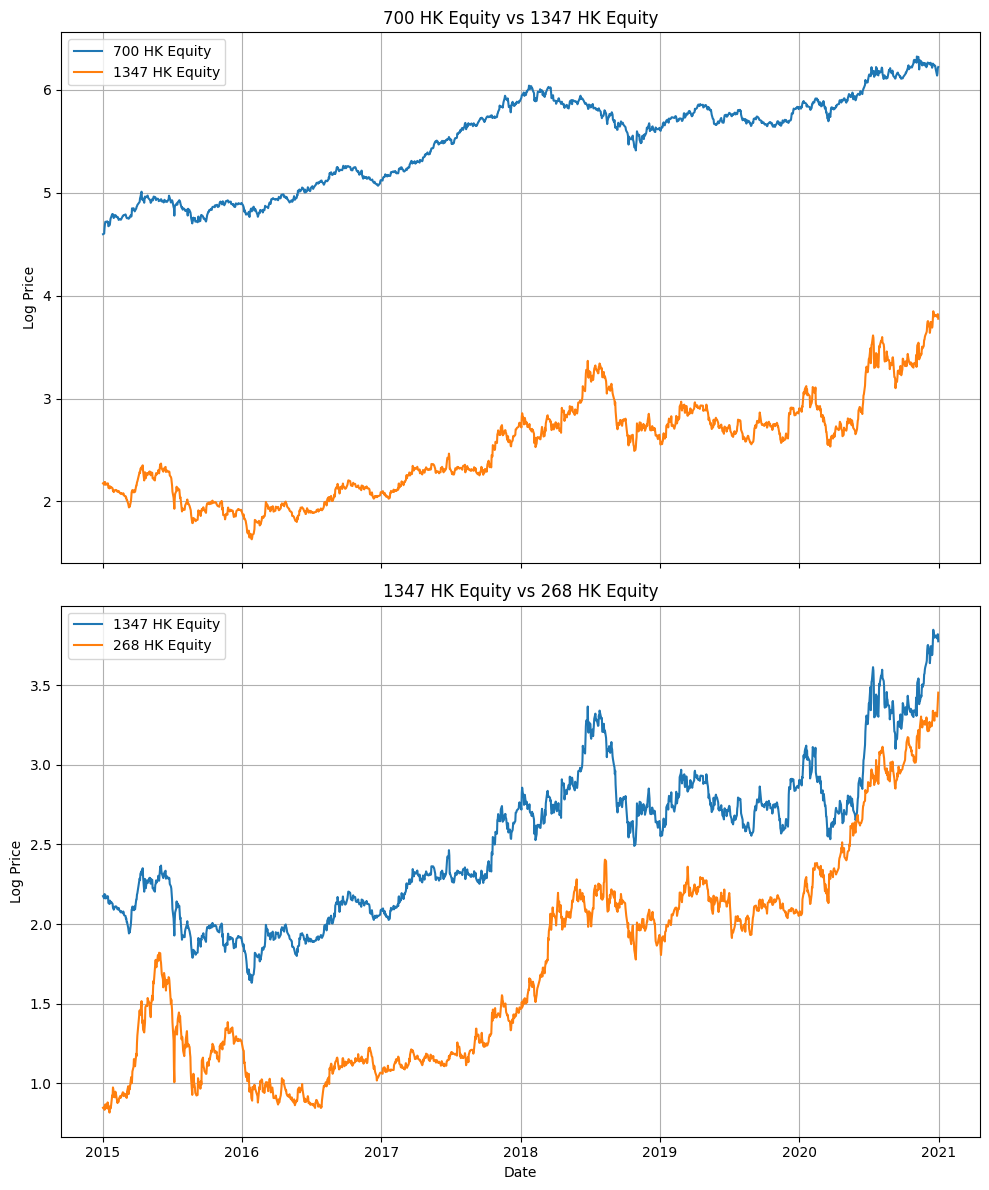

In [9]:
# Log Price Plot

pairs_t = [tuple(p.split("-")) for p in summary_coint_t["pair"]]

plot_multiple_price_pairs(df1_is, pairs_t)

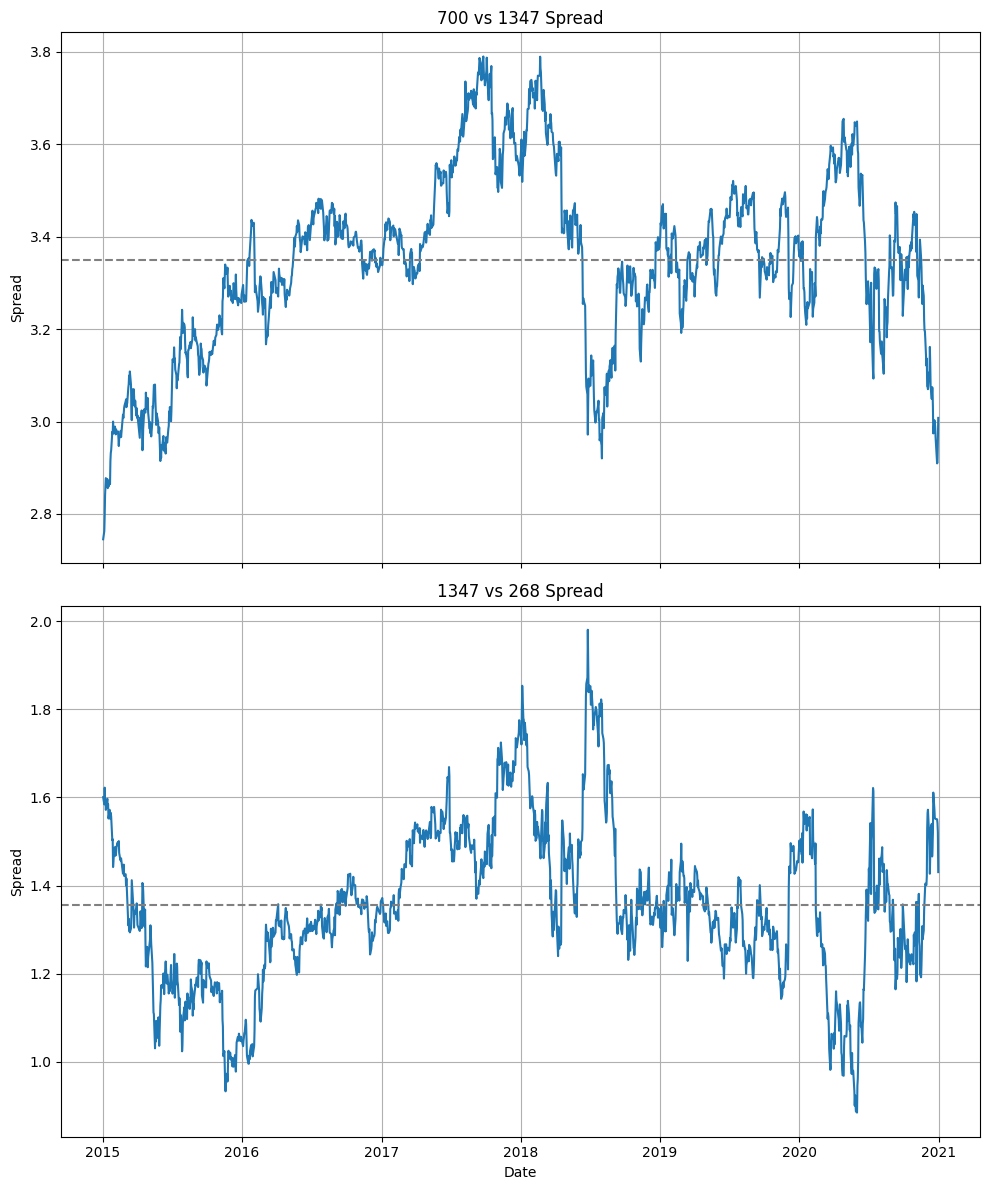

In [10]:
# Calculate spread
spread_t1 = compute_spread(df1_is["700 HK Equity"], 
                           df1_is["1347 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[0])

spread_t2 = compute_spread(df1_is["1347 HK Equity"], 
                           df1_is["268 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[1])

spread_dict = {
    "700 vs 1347": spread_t1,
    "1347 vs 268": spread_t2
}

plot_multiple_spreads(spread_dict)

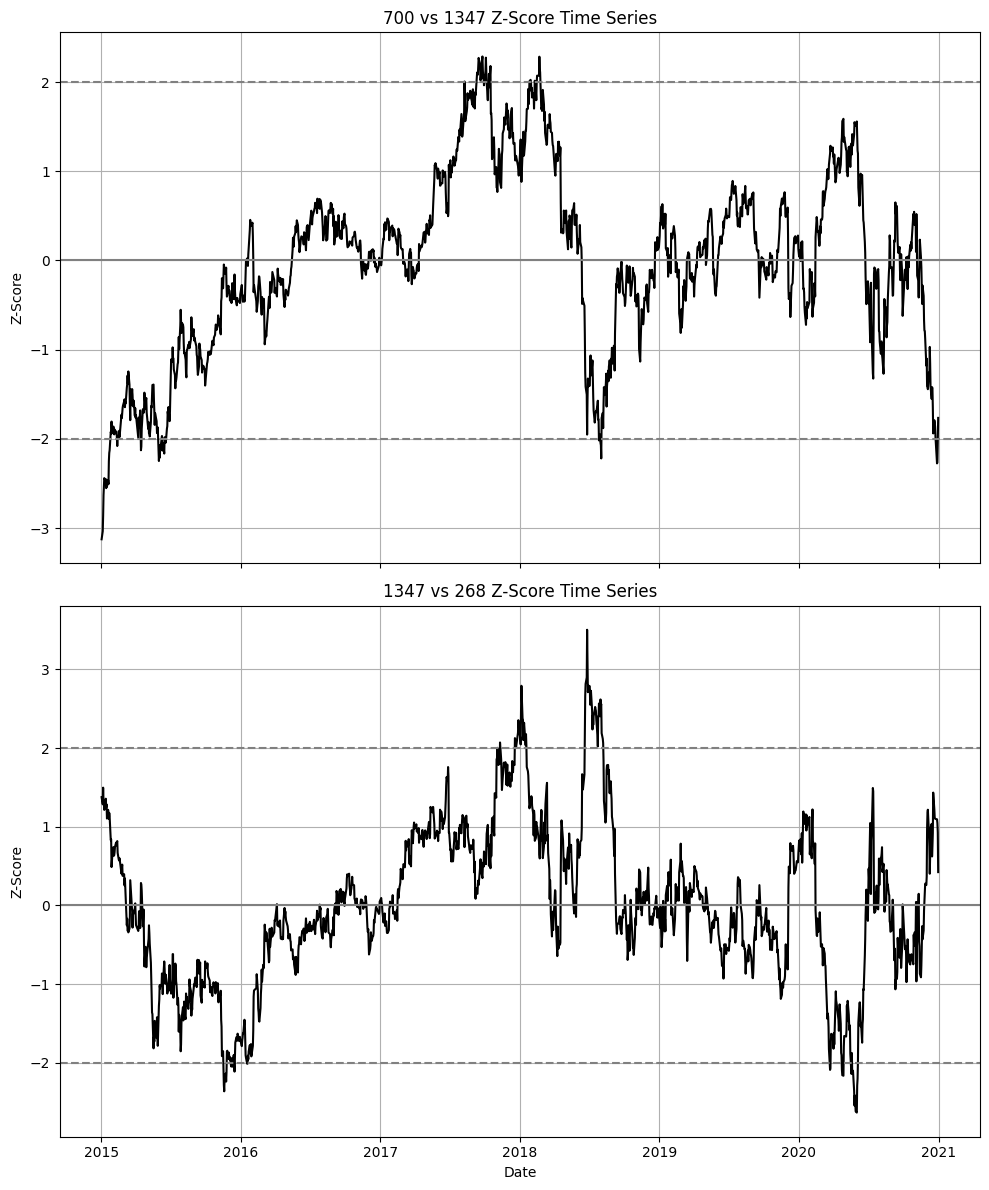

In [11]:
# Calculate z-score
z_t1 = compute_zscore(spread_t1)
z_t2 = compute_zscore(spread_t2)

z_dict = {
    "700 vs 1347": z_t1,
    "1347 vs 268": z_t2
}

plot_multiple_zscores(z_dict)

## Commodities Pairs
*Remember to drop 189 and 1378 as they are have missing data*

In [12]:
# Drop 189 and 1378 HK Equity 
df2_is = df2_is.drop(columns=["189 HK Equity", "1378 HK Equity"])
df2_oos = df2_oos.drop(columns=["189 HK Equity", "1378 HK Equity"])

# Generate pairs 
pairs_c = list(combinations(df2_is.columns, 2))
pairs_c

[('857 HK Equity', '883 HK Equity'),
 ('857 HK Equity', '1088 HK Equity'),
 ('857 HK Equity', '2899 HK Equity'),
 ('857 HK Equity', '386 HK Equity'),
 ('857 HK Equity', '3993 HK Equity'),
 ('857 HK Equity', '2600 HK Equity'),
 ('857 HK Equity', '1898 HK Equity'),
 ('857 HK Equity', '1171 HK Equity'),
 ('857 HK Equity', '358 HK Equity'),
 ('857 HK Equity', '1818 HK Equity'),
 ('857 HK Equity', '1208 HK Equity'),
 ('857 HK Equity', '2099 HK Equity'),
 ('857 HK Equity', '2883 HK Equity'),
 ('857 HK Equity', '3939 HK Equity'),
 ('857 HK Equity', '1258 HK Equity'),
 ('857 HK Equity', '3330 HK Equity'),
 ('857 HK Equity', '1164 HK Equity'),
 ('857 HK Equity', '2689 HK Equity'),
 ('857 HK Equity', '2386 HK Equity'),
 ('857 HK Equity', '3899 HK Equity'),
 ('883 HK Equity', '1088 HK Equity'),
 ('883 HK Equity', '2899 HK Equity'),
 ('883 HK Equity', '386 HK Equity'),
 ('883 HK Equity', '3993 HK Equity'),
 ('883 HK Equity', '2600 HK Equity'),
 ('883 HK Equity', '1898 HK Equity'),
 ('883 HK Equity

In [13]:
# Create dictionary for cointegration test and run it for each pair using the for loop below
results_c = {}

for x, y in pairs_c:
    pair_name = f"{x}-{y}"   
    
    res = analyze_pair(
        y_series=df2_is[x],
        x_series=df2_is[y],
        pair_name=pair_name  
    )
    
    results_c[pair_name] = res

In [14]:
summary_c = summarize_results(results_c)
summary_c

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
0,857 HK Equity-883 HK Equity,1478,1,1,False,0.080052,0.745969,0.898711,NaN,"Residual is not stationary, so the pair is not..."
1,857 HK Equity-1088 HK Equity,1478,1,1,False,-0.087768,0.671749,0.856381,NaN,"Residual is not stationary, so the pair is not..."
2,857 HK Equity-2899 HK Equity,1478,1,1,False,-0.590080,0.053093,0.154328,NaN,"Residual is not stationary, so the pair is not..."
3,857 HK Equity-386 HK Equity,1478,1,1,False,0.884930,0.633689,0.833203,NaN,"Residual is not stationary, so the pair is not..."
4,857 HK Equity-3993 HK Equity,1478,1,1,False,-0.142705,0.603421,0.811985,NaN,"Residual is not stationary, so the pair is not..."
...,...,...,...,...,...,...,...,...,...,...
205,1164 HK Equity-2386 HK Equity,1478,1,1,False,0.712805,0.204648,0.421974,NaN,"Residual is not stationary, so the pair is not..."
206,1164 HK Equity-3899 HK Equity,1478,1,1,False,0.233005,0.399273,0.647569,NaN,"Residual is not stationary, so the pair is not..."
207,2689 HK Equity-2386 HK Equity,1478,1,1,False,0.064673,0.646581,0.840774,NaN,"Residual is not stationary, so the pair is not..."
208,2689 HK Equity-3899 HK Equity,1478,1,1,False,0.342575,0.628961,0.829303,NaN,"Residual is not stationary, so the pair is not..."


In [15]:
summary_coint_c = summary_c[summary_c["cointegrated"]]
summary_coint_c

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
41,1088 HK Equity-3993 HK Equity,1478,1,1,True,0.474138,0.002729,0.012815,-0.015169,Cointegrated
44,1088 HK Equity-1171 HK Equity,1478,1,1,True,0.646130,0.012279,0.046498,-0.015507,Cointegrated
102,3993 HK Equity-2689 HK Equity,1478,1,1,True,1.213595,0.000268,0.001616,-0.018027,Cointegrated
130,1898 HK Equity-2386 HK Equity,1478,1,1,True,0.607067,0.006143,0.025991,-0.012676,Cointegrated


In [16]:
# Creating strong and weak pairs (to explore more pair options)

strong_pairs_c = summary_c[
    (summary_c["cointegrated"] == True) & 
    (summary_c["coint_test_pvalue"] < 0.05)]

weaker_pairs_c = summary_c[
    (summary_c["coint_test_pvalue"] < 0.10) &
    (summary_c["coint_test_pvalue"] >= 0.05)
]

# strong_pairs_c.sort_values("coint_test_pvalue").head(10)
weaker_pairs_c.sort_values("coint_test_pvalue").head(10)

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
161,1818 HK Equity-1164 HK Equity,1478,1,1,False,-0.467074,0.018599,0.065699,NaN,"Residual is not stationary, so the pair is not..."
18,857 HK Equity-2386 HK Equity,1478,1,1,False,0.884939,0.033274,0.079592,NaN,"Residual is not stationary, so the pair is not..."


### Visualising pairs

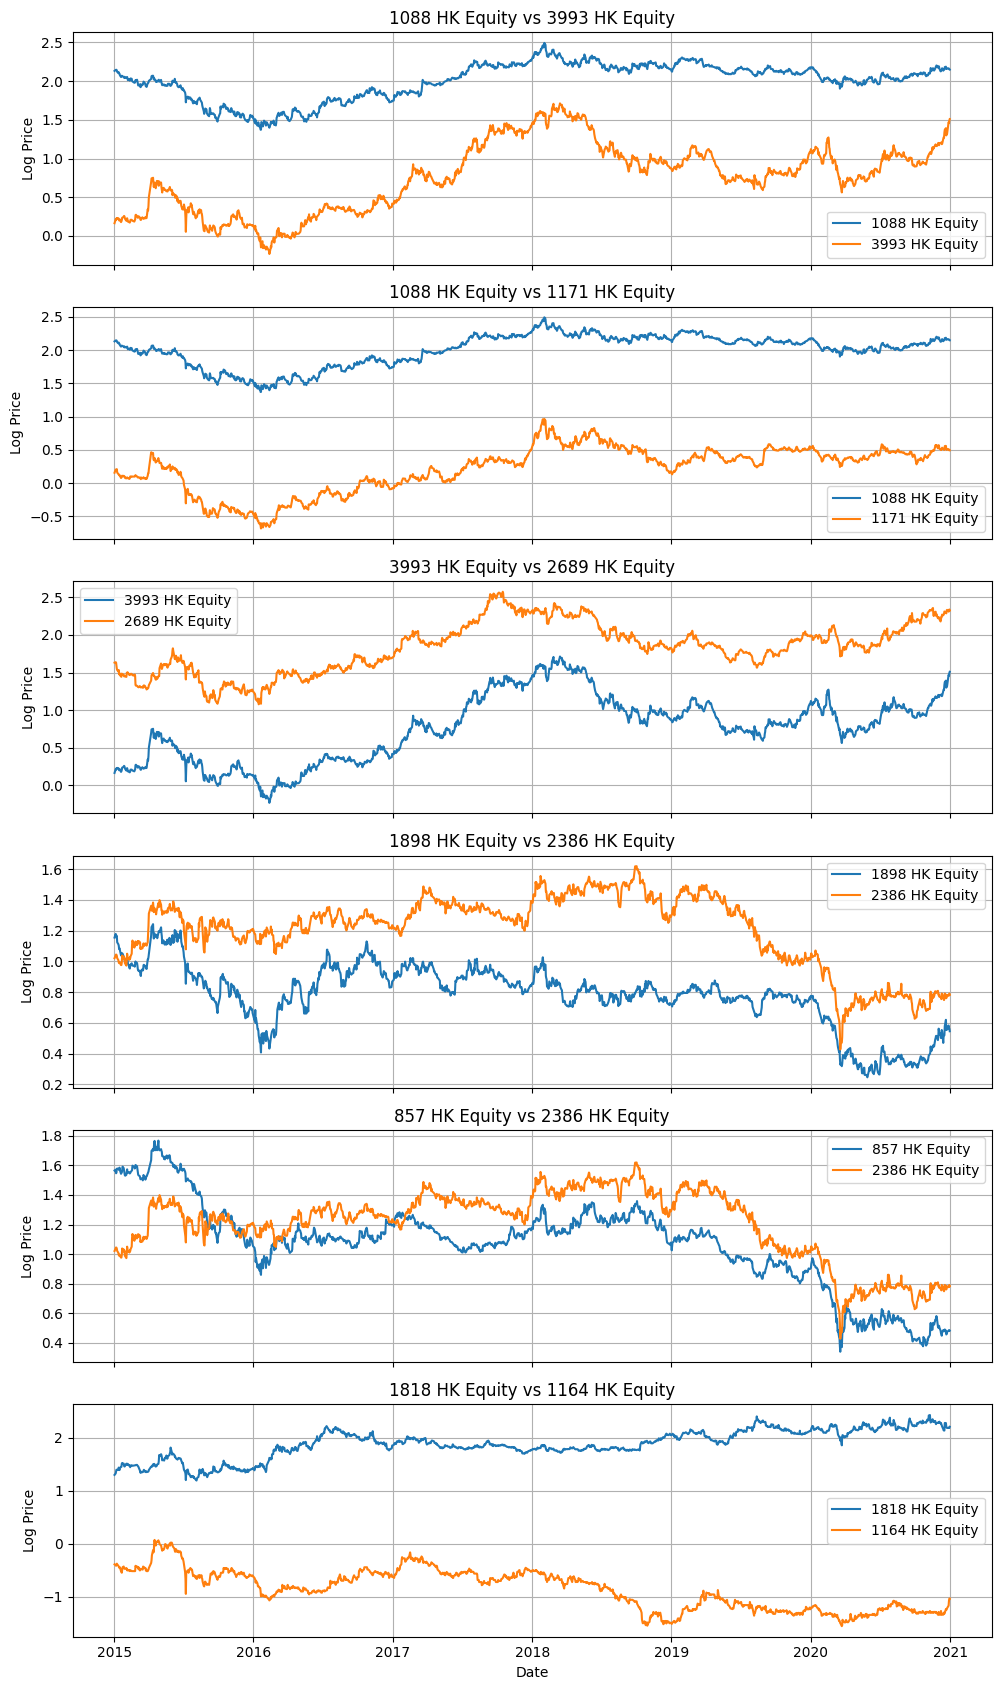

In [17]:
# Log Price Plot

pairs_c1 = [tuple(x.strip() for x in p.split("-")) for p in summary_coint_c["pair"]]
pairs_c2 = [tuple(x.strip() for x in p.split("-")) for p in weaker_pairs_c["pair"]]

pairs_c = pairs_c1 + pairs_c2

plot_multiple_price_pairs(df2_is, pairs_c, figsize=(10,17))

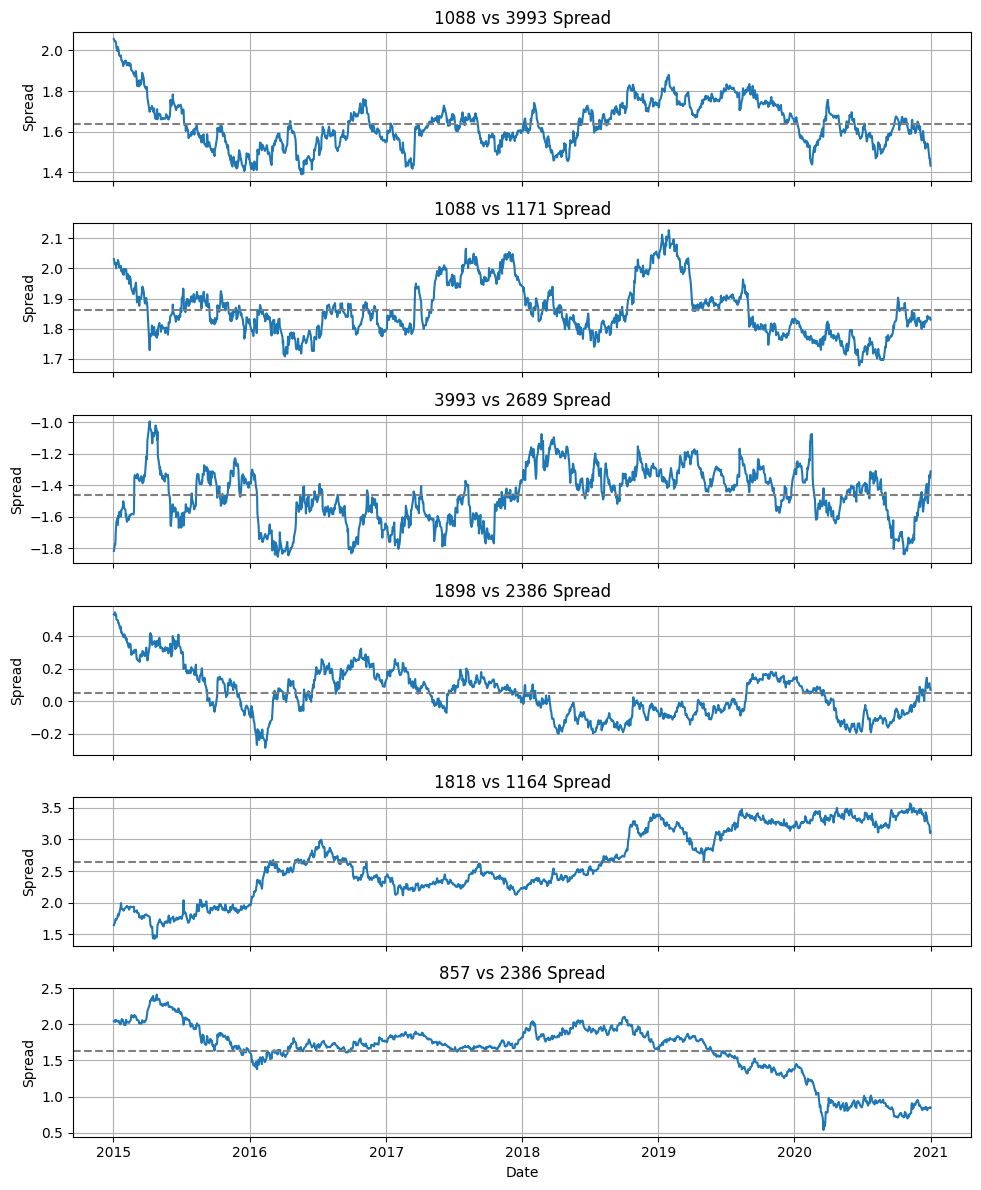

In [18]:
# Calculate spread
spread_c1 = compute_spread(df2_is["1088 HK Equity"], 
                           df2_is["3993 HK Equity"], 
                           summary_coint_c["hedge_ratio"].iloc[0])

spread_c2 = compute_spread(df2_is["1088 HK Equity"], 
                           df2_is["1171 HK Equity"], 
                           summary_coint_c["hedge_ratio"].iloc[1])

spread_c3 = compute_spread(df2_is["3993 HK Equity"], 
                           df2_is["2689 HK Equity"], 
                           summary_coint_c["hedge_ratio"].iloc[2])

spread_c4 = compute_spread(df2_is["1898 HK Equity"], 
                           df2_is["2386 HK Equity"], 
                           summary_coint_c["hedge_ratio"].iloc[3])

spread_c5 = compute_spread(df2_is["1818 HK Equity"], 
                           df2_is["1164 HK Equity"], 
                           weaker_pairs_c["hedge_ratio"].iloc[0])

spread_c6 = compute_spread(df2_is["857 HK Equity"], 
                           df2_is["2386 HK Equity"], 
                           weaker_pairs_c["hedge_ratio"].iloc[1])

spread_dict_c = {
    "1088 vs 3993": spread_c1,
    "1088 vs 1171": spread_c2,
    "3993 vs 2689": spread_c3,
    "1898 vs 2386": spread_c4,
    "1818 vs 1164": spread_c5,
    "857 vs 2386": spread_c6
}

plot_multiple_spreads(spread_dict_c)

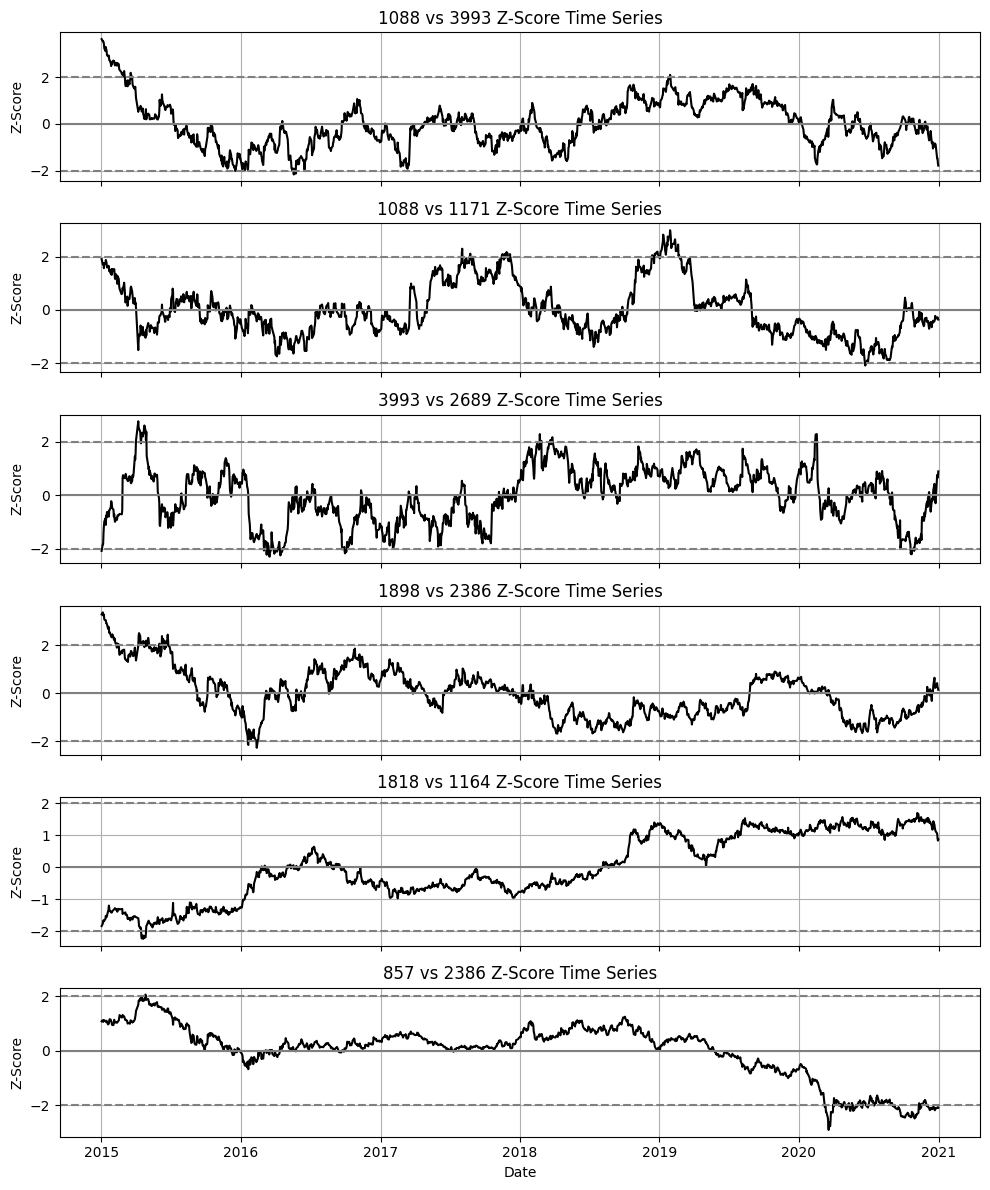

In [19]:
# Calculate z-score
z_c1 = compute_zscore(spread_c1)
z_c2 = compute_zscore(spread_c2)
z_c3 = compute_zscore(spread_c3)
z_c4 = compute_zscore(spread_c4)
z_c5 = compute_zscore(spread_c5)
z_c6 = compute_zscore(spread_c6)

z_dict_c = {
    "1088 vs 3993": z_c1,
    "1088 vs 1171": z_c2,
    "3993 vs 2689": z_c3,
    "1898 vs 2386": z_c4,
    "1818 vs 1164": z_c5,
    "857 vs 2386": z_c6

}

plot_multiple_zscores(z_dict_c)

### Testing pairs on rolling cointegration for additional statistical rigour 

We use our **analyze_rolling_pair** function to test for this

In [20]:
# Create dictionary for y_series and x_series [using the pairs that we identified from above]

pairs_rolling = [
    {"y": "700 HK Equity", "x": "1347 HK Equity", "df": df1_is},
    {"y": "1347 HK Equity", "x": "268 HK Equity", "df": df1_is},
    {"y": "1088 HK Equity", "x": "3993 HK Equity", "df": df2_is},
    {"y": "1088 HK Equity", "x": "1171 HK Equity", "df": df2_is},
    {"y": "3993 HK Equity", "x": "2689 HK Equity", "df": df2_is},
    {"y": "1898 HK Equity", "x": "2386 HK Equity", "df": df2_is},
    {"y": "857 HK Equity", "x": "2386 HK Equity", "df": df2_is},
    {"y": "1818 HK Equity", "x": "1164 HK Equity", "df": df2_is},
]

In [21]:
# Run the rolling cointegration test
results_rolling = []

for pair in pairs_rolling:
    y_series = pair["df"][pair["y"]]
    x_series = pair["df"][pair["x"]]
    
    result = analyze_rolling_pair(
        y_series,
        x_series,
        pair_name=f"{pair['y']} vs {pair['x']}"
    )
    
    results_rolling.append(result)

In [22]:
rolling_res = summarize_results_list(results_rolling) 
rolling_res.head(10)

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
0,700 HK Equity vs 1347 HK Equity,1478,1,1,True,0.851246,0.010985,0.042348,-0.003120,Cointegration
1,1347 HK Equity vs 268 HK Equity,1478,1,1,True,0.679160,0.008580,0.034350,-0.015993,Cointegration
2,1088 HK Equity vs 3993 HK Equity,1478,1,1,True,0.474138,0.002729,0.012815,-0.015169,Cointegration
3,1088 HK Equity vs 1171 HK Equity,1478,1,1,True,0.646130,0.012279,0.046498,-0.015507,Cointegration
4,3993 HK Equity vs 2689 HK Equity,1478,1,1,True,1.213595,0.000268,0.001616,-0.018027,Cointegration
5,1898 HK Equity vs 2386 HK Equity,1478,1,1,True,0.607067,0.006143,0.025991,-0.012676,Cointegration
6,857 HK Equity vs 2386 HK Equity,1478,1,1,False,0.884939,0.033274,0.079592,NaN,Residual is not stationary or coint() does not...
7,1818 HK Equity vs 1164 HK Equity,1478,1,1,False,-0.467074,0.018599,0.065699,NaN,Residual is not stationary or coint() does not...


In [23]:
# Keep the pairs which passed the rolling cointegration test 
trading_pairs = rolling_res[rolling_res["cointegrated"] == True]
trading_pairs.head()

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
0,700 HK Equity vs 1347 HK Equity,1478,1,1,True,0.851246,0.010985,0.042348,-0.003120,Cointegration
1,1347 HK Equity vs 268 HK Equity,1478,1,1,True,0.679160,0.008580,0.034350,-0.015993,Cointegration
2,1088 HK Equity vs 3993 HK Equity,1478,1,1,True,0.474138,0.002729,0.012815,-0.015169,Cointegration
3,1088 HK Equity vs 1171 HK Equity,1478,1,1,True,0.646130,0.012279,0.046498,-0.015507,Cointegration
4,3993 HK Equity vs 2689 HK Equity,1478,1,1,True,1.213595,0.000268,0.001616,-0.018027,Cointegration
